In [ ]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import re


# Ruta del dataset
INPUT_CSV = "/data/filtered_H-AIRosettaMP.csv"

# Función para limpiar código fuente
def clean_code(code):
    # Elimina comentarios de una sola línea (// ...)
    code = re.sub(r'//.*', '', code)

    # Elimina comentarios multilínea (/* ... */)
    code = re.sub(r'/\*.*?\*/', '', code, flags=re.DOTALL)

    # Normaliza espacios (muchos espacios → uno solo)
    code = re.sub(r'\s+', ' ', code)

    return code.strip()  # Quita espacios al inicio y final

# Cargar dataset
df = pd.read_csv(
    INPUT_CSV,
    encoding="latin1",
    engine="python"
)
# Aplicar limpieza al código
df["code_clean"] = df["code"].astype(str).apply(clean_code)

# Normalizar etiquetas (lowercase y sin espacios extra)
df["target"] = df["target"].astype(str).str.strip().str.lower()

# Mapear etiquetas a valores numéricos
label_map = {
    "human_written": 0,
    "ai_generated": 1
}

df["target_num"] = df["target"].map(label_map)

# Eliminar filas donde no se pudo mapear la etiqueta
df = df.dropna(subset=["target_num"])

# Mostrar distribución de clases
print("Distribución:", df["target_num"].value_counts())

# Verificar que hay exactamente 2 clases
assert df["target_num"].nunique() == 2, "Solo hay una clase"

# Extraer datos
codes = df["code_clean"].tolist()  # lista de códigos limpios
y = df["target_num"].values        # etiquetas

# Cargar modelo preentrenado CodeBERT
model = SentenceTransformer("microsoft/codebert-base")

# Convertir código a embeddings (vectores numéricos)
X = model.encode(
    codes,
    batch_size=64,
    show_progress_bar=True
)

# Convertir a array de numpy
X = np.array(X)

# División del dataset:
# 70% entrenamiento, 30% temporal (validación + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Dividir el 30% restante en:
# 15% validación y 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# Crear modelo de regresión logística
clf = LogisticRegression(max_iter=2000)

# Entrenar el modelo con los embeddings
clf.fit(X_train, y_train)

print("✅ Modelo entrenado")

print("Train:", X_train.shape, len(y_train))
print("Validation:", X_val.shape, len(y_val))
print("Test:", X_test.shape, len(y_test))

Distribución: target_num
1    7456
0    3420
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Batches:   0%|          | 0/170 [00:00<?, ?it/s]

✅ Modelo entrenado
Train: (7613, 768) 7613
Validation: (1631, 768) 1631
Test: (1632, 768) 1632


In [ ]:
raw_lines = sum(1 for _ in open(INPUT_CSV, encoding="latin1"))
print("Líneas en archivo:", raw_lines)

print("Filas cargadas en DataFrame:", len(df))

Líneas en archivo: 409402
Filas cargadas en DataFrame: 10876


In [ ]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    recall_score,
    accuracy_score,
    precision_score
)

def evaluate_threshold(X, y, model, threshold):
    probs = model.predict_proba(X)[:, 1]
    y_pred = (probs >= threshold).astype(int)

    cm = confusion_matrix(y, y_pred)

    acc = accuracy_score(y, y_pred)
    recall = recall_score(y, y_pred)
    precision = precision_score(y, y_pred)

    # F1 por clase
    f1_per_class = f1_score(y, y_pred, average=None)

    print(f"\nThreshold = {threshold}")
    print("Accuracy:", acc)
    print("Recall:", recall)
    print("Precision:", precision)
    print("F1 por clase [human, ai]:", f1_per_class)
    print("Confusion Matrix:\n", cm)


for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    evaluate_threshold(X_val, y_val, clf, t)


Threshold = 0.1
Accuracy: 0.6928264868179032
Recall: 0.9991055456171736
Precision: 0.6907854050711194
F1 por clase [human, ai]: [0.04933586 0.81681901]
Confusion Matrix:
 [[  13  500]
 [   1 1117]]

Threshold = 0.2
Accuracy: 0.7173513182096873
Recall: 0.9901610017889088
Precision: 0.7109826589595376
F1 por clase [human, ai]: [0.21465077 0.82766355]
Confusion Matrix:
 [[  63  450]
 [  11 1107]]

Threshold = 0.3
Accuracy: 0.7431023911710607
Recall: 0.9758497316636852
Precision: 0.7356709372892785
F1 por clase [human, ai]: [0.36611195 0.83890811]
Confusion Matrix:
 [[ 121  392]
 [  27 1091]]

Threshold = 0.4
Accuracy: 0.7614960147148988
Recall: 0.9409660107334525
Precision: 0.765090909090909
F1 por clase [human, ai]: [0.49414824 0.8439631 ]
Confusion Matrix:
 [[ 190  323]
 [  66 1052]]

Threshold = 0.5
Accuracy: 0.7792765174739423
Recall: 0.8917710196779964
Precision: 0.8066343042071198
F1 por clase [human, ai]: [0.60352423 0.84706882]
Confusion Matrix:
 [[274 239]
 [121 997]]

Threshold

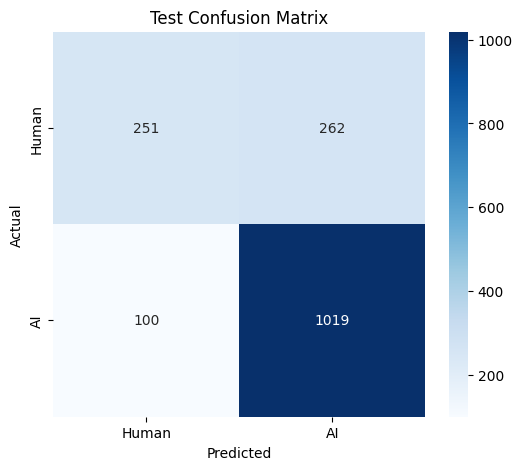

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(X, y, model, title="Confusion Matrix"):
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Human", "AI"],
        yticklabels=["Human", "AI"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

# Ejemplo:
plot_confusion_matrix(X_test, y_test, clf, "Test Confusion Matrix")

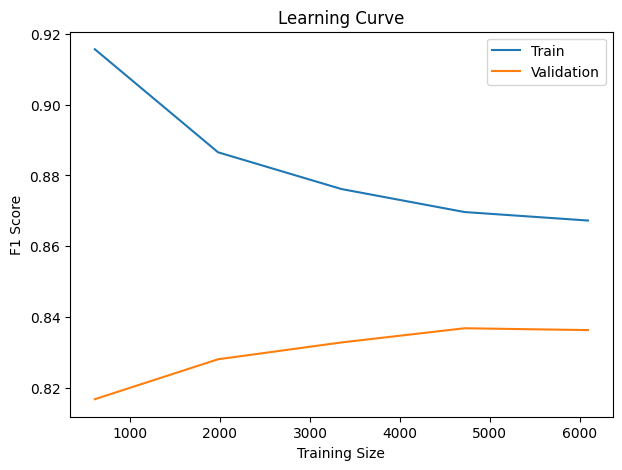

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

def plot_learning_curve(model, X, y):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring="f1",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    plt.figure(figsize=(7,5))
    sns.lineplot(x=train_sizes, y=train_mean, label="Train")
    sns.lineplot(x=train_sizes, y=val_mean, label="Validation")

    plt.xlabel("Training Size")
    plt.ylabel("F1 Score")
    plt.title("Learning Curve")
    plt.legend()
    plt.show()

# Ejemplo:
plot_learning_curve(clf, X_train, y_train)